In [1]:
def EXTRACT_MBQ ( line ):
    if "MBQ" in line.info:
        mbq_value = line.info["MBQ"]
        if isinstance(mbq_value, str):
            mbq_list = mbq_value.split(",")
        elif isinstance(mbq_value, (list, tuple)):
            mbq_list = [str(x) for x in mbq_value]
        else:
            mbq_list = [str(mbq_value)]

        if len(mbq_list) >= 2:
            mbq_second = mbq_list[1]
        else:
            mbq_second = None
        
        return mbq_second
    else:
        return None
    
def EXTRACT_TLOD ( line ):
    if "TLOD" in line.info:
        TLOD_value = round ( float ( line.info["TLOD"][0] ), 2 )
        return TLOD_value
    else:
        return None

def FIND_CONTROL_SAMPLES ( samplenames, str_contain = "Blood" ):
    for i, samplename in enumerate(samplenames):
        if str_contain in samplename:
            return i, samplename


In [19]:
import os, glob, pysam
import pandas as pd
import numpy as np

MUTECT_DIR="/data/project/Meningioma/04.mutect"


vcf_files = [f for f in glob.glob ( MUTECT_DIR + "/02.PASS/" + "*220930_1*Tumor*MT2.FMC.HF.RMBLACK.vcf") if "single" not in os.path.basename(f)]
vcf_files = [ MUTECT_DIR + "/05.Shared_variant/220930_1_Dura.MT2.FMC.HF.RMBLACK.shared_variant.vcf",  
                MUTECT_DIR + "/05.Shared_variant/220930_2_Dura.MT2.FMC.HF.RMBLACK.shared_variant.vcf" ]

# vcf_files = [ MUTECT_DIR + "/02.PASS/241016_Tumor.MT2.FMC.HF.RMBLACK.vcf",  
#                 MUTECT_DIR + "/02.PASS/241211_Tumor.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250425_Tumor.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250502_Tumor.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250509_Tumor.MT2.FMC.HF.RMBLACK.vcf",
#                  MUTECT_DIR + "/02.PASS/241016_DT.MT2.FMC.HF.RMBLACK.vcf",  
#                 MUTECT_DIR + "/02.PASS/241211_DT.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250425_DT.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250212_Falx.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250502_DT.MT2.FMC.HF.RMBLACK.vcf",
#                 MUTECT_DIR + "/02.PASS/250509_DT.MT2.FMC.HF.RMBLACK.vcf",
#                  ]

vcf_files = [ MUTECT_DIR + "/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf",  
                MUTECT_DIR + "/02.PASS/SMS_2nd_Tumor.MT2.FMC.HF.RMBLACK.vcf",
                MUTECT_DIR + "/02.PASS/SMS_3rd_Tumor.MT2.FMC.HF.RMBLACK.vcf",
                MUTECT_DIR + "/02.PASS/SMS_4th_Tumor.MT2.FMC.HF.RMBLACK.vcf",
                MUTECT_DIR + "/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf"
                 ]

vcf_files = [ MUTECT_DIR + "/02.PASS/241016_Tumor.MT2.FMC.HF.RMBLACK.vcf",  
                MUTECT_DIR + "/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf"
                 ]

vcf_files = []
TN_list = [ "230802_2", "230419", "241023", "221102", "240403_3", "240412_2", "230127", "190524", "240320", "231025", "230920", "230822", "230405_2", "221202", "231006", "241127" ]
PC_list = [ "221026", "240110", "220930_1", "241016", "250212" ]
sample_list = TN_list + PC_list
for Sample_ID in sample_list:
    vcf_files += [ MUTECT_DIR + "/02.PASS/{}_Tumor.MT2.FMC.HF.RMBLACK.vcf".format(Sample_ID) ]


df_acc = pd.DataFrame( columns = [ "CHR", "POS", "REF", "ALT", "MBQ", "TLOD", "AF", "DP_COUNT", "ALT_COUNT", "Sample_ID"] )

for vcf_file in vcf_files:
    df = pd.DataFrame( columns = ["CHR", "POS", "REF", "ALT", "MBQ", "TLOD", "AF", "DP_COUNT", "ALT_COUNT"] )
    print(f"Processing: {vcf_file}")
    with pysam.VariantFile(vcf_file) as vcf:
        for line in vcf.fetch():
            MBQ = EXTRACT_MBQ  ( line )
            TLOD = EXTRACT_TLOD  ( line )

            # if TLOD < 10:
            #     continue
            
            samplenames = list(vcf.header.samples)
            control_index, control_samplename = FIND_CONTROL_SAMPLES ( samplenames, str_contain = "Blood" )
            AF = None
            for i, samplename in enumerate(samplenames):
                if i == control_index:     # Blood면 제외
                    continue
                
                sample = line.samples[ samplename ]   # 현재 sample의 line 정보
                # AF가 FORMAT에 있을 경우
                if "AF" in sample:
                    af_value = sample["AF"]
                    # AF가 리스트나 튜플일 수 있으므로 첫 번째 값만 사용
                    if isinstance(af_value, (list, tuple)):
                        AF = af_value[0]
                    else:
                        AF = af_value
                # 만약 AF가 없고, AD(Allele Depth)로부터 계산해야 할 경우
                if "AD" in sample:
                    ad = sample["AD"]
                    if isinstance(ad, (list, tuple)) and len(ad) >= 2:
                        ref_count = int ( ad[0] )
                        alt_count = int ( ad[1] )
                        if (ref_count + alt_count) > 0:
                            AF = round(alt_count / (ref_count + alt_count), 4)
                        else:
                            AF = None

            df.loc [ df.shape[0], ]= [ line.chrom, line.pos, line.ref, line.alts[0], int(MBQ), TLOD, AF, ref_count  + alt_count, alt_count ]
    df["Sample_ID"] = vcf_file.replace(MUTECT_DIR, "")
    
    df_acc = pd.concat( [df_acc, df], ignore_index = True )

df_acc = df_acc.astype ( { "MBQ" :  int, "TLOD" :  float, "AF" :  float, "DP_COUNT": int, "ALT_COUNT": int} )
# df_acc.to_csv ( MUTECT_DIR + "/" + "250207_Tumor_MBQ_TLOD.csv", index = False )

Processing: /data/project/Meningioma/04.mutect/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/230419_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/241023_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/221102_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/240403_3_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/240412_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/230127_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/190524_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/240320_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/231025_Tumor.MT2.FMC.HF.RMBLACK.vcf
Processing: /data/project/Meningioma/04.mutect/02.PASS/230920_Tumor.MT2.FMC.HF.RMBLA

In [20]:
df_acc

,CHR,POS,REF,ALT,MBQ,TLOD,AF,DP_COUNT,ALT_COUNT,Sample_ID
0,chr1,43364068,G,T,25,7.40,0.0321,156,5,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
1,chr7,149432483,G,T,30,7.04,0.0088,1023,9,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
2,chr12,64759162,C,A,31,6.66,0.0645,62,4,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
3,chr16,795846,C,G,29,389.80,0.2865,569,163,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
4,chr17,2691578,G,T,32,8.34,0.0139,720,10,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf
...,...,...,...,...,...,...,...,...,...,...
394,chr11,124265842,C,T,38,12.65,0.0300,200,6,/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf
395,chr14,73944442,C,T,38,142.07,0.3600,125,45,/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf
396,chr19,43966000,A,G,38,35.95,0.0761,197,15,/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf
397,chr22,29642268,T,TA,36,100.63,0.5862,58,34,/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf


In [21]:
def GROUP_BY_SAMPLE_ID ( df ):
    # Sample_ID별로 count와 mean 계산 (소수점 1자리에서 반올림)
    grouped = df.groupby("Sample_ID").agg(
        count=("TLOD", "count"),
        mean_TLOD=("TLOD", "mean"),
        mean_MBQ=("MBQ", "mean"),
        mean_AF=("AF", "mean")
    ).reset_index()

    # 소수점 1자리에서 반올림
    grouped["mean_TLOD"] = grouped["mean_TLOD"].round(1)
    grouped["mean_MBQ"] = grouped["mean_MBQ"].round(1)
    grouped["mean_AF"] = grouped["mean_AF"].round(2)

    return grouped

GROUP_BY_SAMPLE_ID  ( df_acc  )


,Sample_ID,count,mean_TLOD,mean_MBQ,mean_AF
0,/02.PASS/190524_Tumor.MT2.FMC.HF.RMBLACK.vcf,14,59.8,36.8,0.18
1,/02.PASS/220930_1_Tumor.MT2.FMC.HF.RMBLACK.vcf,26,109.5,22.4,0.25
2,/02.PASS/221026_Tumor.MT2.FMC.HF.RMBLACK.vcf,29,137.0,22.2,0.31
3,/02.PASS/221102_Tumor.MT2.FMC.HF.RMBLACK.vcf,17,58.2,36.3,0.16
4,/02.PASS/221202_Tumor.MT2.FMC.HF.RMBLACK.vcf,16,111.9,35.6,0.31
5,/02.PASS/230127_Tumor.MT2.FMC.HF.RMBLACK.vcf,28,64.9,22.7,0.15
6,/02.PASS/230405_2_Tumor.MT2.FMC.HF.RMBLACK.vcf,15,121.0,36.0,0.28
7,/02.PASS/230419_Tumor.MT2.FMC.HF.RMBLACK.vcf,40,62.9,22.8,0.15
8,/02.PASS/230802_2_Tumor.MT2.FMC.HF.RMBLACK.vcf,6,83.5,29.3,0.18
9,/02.PASS/230822_Tumor.MT2.FMC.HF.RMBLACK.vcf,16,103.9,36.4,0.32


In [8]:
GROUP_BY_SAMPLE_ID  ( df_acc[  (df_acc["ALT_COUNT"] >= 2) ] )

,Sample_ID,count,mean_TLOD,mean_MBQ,mean_AF
0,/02.PASS/241016_Tumor.MT2.FMC.HF.RMBLACK.vcf,65,14.8,37.0,0.05
1,/02.PASS/250212_Tumor.MT2.FMC.HF.RMBLACK.vcf,41,22.2,35.5,0.08


In [32]:
#GROUP_BY_SAMPLE_ID  ( df_acc[(df_acc["TLOD"] > 5) & (df_acc["MBQ"] > 30)] )
GROUP_BY_SAMPLE_ID  ( df_acc[  (df_acc["MBQ"] > 27 ) ] )

,Sample_ID,count,mean_TLOD,mean_MBQ,mean_AF
0,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf,69,48.8,36.3,0.14
1,/02.PASS/SMS_2nd_Tumor.MT2.FMC.HF.RMBLACK.vcf,49,24.8,32.4,0.07
2,/02.PASS/SMS_3rd_Tumor.MT2.FMC.HF.RMBLACK.vcf,41,101.3,34.3,0.22
3,/02.PASS/SMS_4th_Tumor.MT2.FMC.HF.RMBLACK.vcf,105,18.4,31.2,0.06
4,/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf,70,48.5,36.2,0.14


In [33]:
df_acc[  (df_acc["MBQ"] >= 20) ] 

,CHR,POS,REF,ALT,MBQ,TLOD,AF,DP_COUNT,ALT_COUNT,Sample_ID
0,chr1,26779476,G,T,37,162.53,0.3521,142,50,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf
1,chr1,119836107,G,T,36,10.95,0.0532,94,5,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf
2,chr1,150945182,T,C,36,109.56,0.3617,94,34,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf
3,chr1,168291333,C,A,39,13.07,0.0302,199,6,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf
4,chr1,176556805,G,T,36,11.16,0.0293,205,6,/02.PASS/SMS_1st_Tumor.MT2.FMC.HF.RMBLACK.vcf
...,...,...,...,...,...,...,...,...,...,...
398,chr22,38482554,C,A,20,14.10,0.0617,162,10,/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf
399,chr22,40411620,G,T,20,10.91,0.0714,112,8,/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf
400,chr22,41395807,C,A,20,10.73,0.0597,134,8,/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf
401,chr22,41636452,G,T,37,18.21,0.1045,67,7,/02.PASS/SMS_mets_Tumor.MT2.FMC.HF.RMBLACK.vcf


Text(0.5, 1.0, 'TLOD vs AF scatter plot')

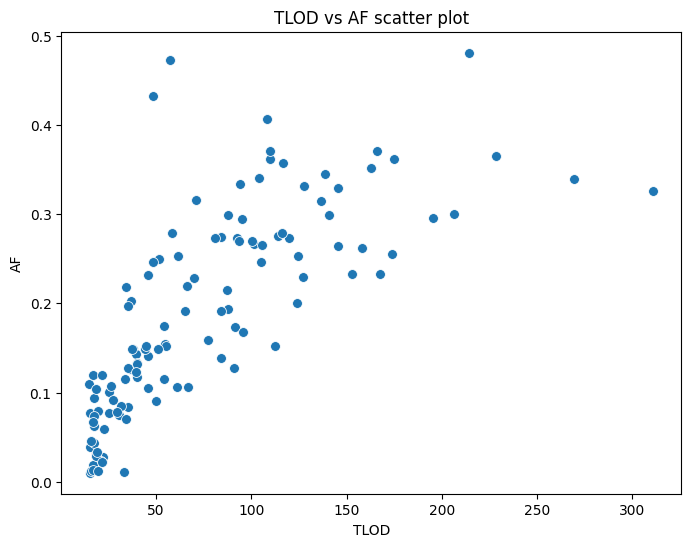

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots( figsize=(8, 6) )
sns.scatterplot(data = df_acc, x="TLOD", y="AF", ax=ax, s = 50)
ax.set_xlabel("TLOD")
ax.set_ylabel("AF")
ax.set_title("TLOD vs AF scatter plot")
# ax.set_xlim(0, 10)
# ax.set_ylim(0, 0.1)

---

## Signature analysis (MuSiCal)

In [ ]:
import os
%matplotlib inline

PROJECT, GENOME,TYPE ="SMS", "hg38", "SOMATIC"

SIGNATURE_DIR = "/data/project/Meningioma/41.Signature/" + PROJECT
subdirs = [ "01.raw_matrix/input", "01.raw_matrix/logs", "01.raw_matrix/output", "02.X_matrix",  "03.MuSiCal"]

for sub in subdirs:
    dir_path = os.path.join(SIGNATURE_DIR, sub)
    os.makedirs(dir_path, exist_ok=True)

# 기존 파일 있으면 삭제
input_file = os.path.join(SIGNATURE_DIR, "01.raw_matrix/input/df_acc.txt")
if os.path.exists(input_file):
    os.remove(input_file)

# 새로 파일 생성 및 컬럼 저장
header = ["Project","Sample","ID","Genome","mut_type","chrom","pos_start","pos_end", "ref", "alt", "Type"]
input_file  = open(input_file, "w")

# SigProfiiler를 이용한 Matrix generation하기 위한 준비
df_acc["Project"] = PROJECT
df_acc["Sample"] = df_acc["Sample_ID"].str.split("/").str[-1].str.split(".").str[0]
df_acc["ID"] = df_acc["CHR"] + ":" + df_acc["POS"].astype(str) + "_" + df_acc["REF"] + "_" + df_acc["ALT"]
df_acc["mut_type"] = df_acc.apply(
    lambda row: "SNP" if len(str(row["REF"])) == len(str(row["ALT"]))
    else ("INS" if len(str(row["ALT"])) > len(str(row["REF"])) else "DEL"),
    axis=1
)
df_acc["Genome"] = GENOME
df_acc["chrom"] = df_acc["CHR"].str.replace("chr", "")
df_acc["pos_start"] = df_acc["POS"]
df_acc["pos_end"] = df_acc["POS"]
df_acc["ref"] = df_acc["REF"]
df_acc["alt"] = df_acc["ALT"]
df_acc["Type"] = TYPE

for k in range(df_acc.shape[0]):
    line = df_acc.iloc[k]
    print("{0}\t{1}\t{2}\t{3}\t{4}\t{5}\t{6}\t{7}\t{8}\t{9}\t{10}".format(
        line['Project'], line['Sample'], line['ID'], line['Genome'], line['mut_type'], line['chrom'], line['pos_start'], line['pos_end'], line['ref'], line['alt'], line['Type']), file=input_file)

input_file.close()





from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen

os.system ( "rm -rf " + SIGNATURE_DIR + "/01.raw_matrix/output " + SIGNATURE_DIR + "/01.raw_matrix/log " )
           
matrices = matGen.SigProfilerMatrixGeneratorFunc ( project = PROJECT,  # project
                                                                                    reference_genome = "GRCh38",   # reference_genome
                                                                                    path_to_input_files  = SIGNATURE_DIR + "/01.raw_matrix",  # path_to_input_files 
                                                                                    exome = False, 
                                                                                    bed_file = None, 
                                                                                    chrom_based = False, 
                                                                                    plot = True, 
                                                                                    tsb_stat = False, 
                                                                                    seqInfo = True)
os.system ( "cp " + SIGNATURE_DIR + "/01.raw_matrix/output/SBS/{}.SBS96.all".format(PROJECT) + " " +
                            SIGNATURE_DIR + "/02.X_matrix")

Starting matrix generation for SNVs and DINUCs...There may be an issue with the formatting of your matrix file.
There may be an issue with the formatting of your matrix file.
There may be an issue with the formatting of your matrix file.
Completed! Elapsed time: 28.97 seconds.
Starting matrix generation for INDELs...There may be an issue with the formatting of your matrix file.
Error: The function plotID does not support plot_type 96ID so no plot has been generated.
Completed! Elapsed time: 3.12 seconds.
Matrices generated for 5 samples with 0 errors. Total of 155 SNVs, 1 DINUCs, and 5 INDELs were successfully analyzed.


0

In [11]:
df_acc ["Sample"].unique().tolist()

['SMS_1st_Tumor',
 'SMS_2nd_Tumor',
 'SMS_3rd_Tumor',
 'SMS_4th_Tumor',
 'SMS_mets_Tumor']

In [12]:
from SigProfilerMatrixGenerator.scripts import SigProfilerMatrixGeneratorFunc as matGen

#os.system ( "rm -rf " + SIGNATURE_DIR + "/01.raw_matrix/input " + SIGNATURE_DIR + "/01.raw_matrix/output " + SIGNATURE_DIR + "/01.raw_matrix/log " )
           
matrices = matGen.SigProfilerMatrixGeneratorFunc ( project = PROJECT,  # project
                                                                                    reference_genome = "GRCh38",   # reference_genome
                                                                                    path_to_input_files  = SIGNATURE_DIR + "/01.raw_matrix",  # path_to_input_files 
                                                                                    exome = False, 
                                                                                    bed_file = None, 
                                                                                    chrom_based = False, 
                                                                                    plot = True, 
                                                                                    tsb_stat = False, 
                                                                                    seqInfo = True)
os.system ( "cp " + SIGNATURE_DIR + "/01.raw_matrix/output/SBS/{}.SBS96.all".format(PROJECT) + " " +
                            SIGNATURE_DIR + "/02.X_matrix")

Starting matrix generation for SNVs and DINUCs...There may be an issue with the formatting of your matrix file.
There may be an issue with the formatting of your matrix file.
There may be an issue with the formatting of your matrix file.
Completed! Elapsed time: 25.12 seconds.
Starting matrix generation for INDELs...There may be an issue with the formatting of your matrix file.
Error: The function plotID does not support plot_type 96ID so no plot has been generated.
Completed! Elapsed time: 3.45 seconds.
Matrices generated for 5 samples with 0 errors. Total of 155 SNVs, 1 DINUCs, and 5 INDELs were successfully analyzed.


0

## MuSiCAl로 decompose 하기

In [13]:
import musical
X = pd.read_csv( SIGNATURE_DIR + "/01.raw_matrix/output/SBS/{}.SBS96.all".format(PROJECT), index_col=0, sep  = "\t")
X.index.name = 'Type'
COLUMN_ORDER = df_acc ["Sample"].unique().tolist()
X = X.loc [ musical.load_catalog('COSMIC-MuSiCal_v3p2_SBS_WGS').W.index , COLUMN_ORDER ]   # 순서를 잘 정해줄 필요가 있다
X

,SMS_1st_Tumor,SMS_2nd_Tumor,SMS_3rd_Tumor,SMS_4th_Tumor,SMS_mets_Tumor
Type,,,,,
A[C>A]A,0,0,0,0,0
A[C>A]C,0,0,0,0,0
A[C>A]G,0,0,0,0,0
A[C>A]T,0,0,0,0,0
C[C>A]A,2,0,0,2,2
...,...,...,...,...,...
G[T>G]T,0,0,0,0,0
T[T>G]A,0,0,0,0,0
T[T>G]C,0,0,0,0,0


### 01. de novo signature discovery ( X만 있으면 됨. 5분 정도)

In [14]:
# 01. de novo signature discovery ( 각 n 별로 오래 걸린다 )

model = musical.DenovoSig(X, 
                          min_n_components = 2, # Minimum number of signatures to test
                          max_n_components = 5, # Maximum number of signatures to test
                          init = 'random', # Initialization method
                          method = 'mvnmf', # mvnmf or nmf
                          n_replicates = 10, # Number of mvnmf/nmf replicates to run per n_components
                          ncpu = 8, # Number of CPUs to use
                          max_iter = 10000, # Maximum number of iterations for each mvnmf/nmf run
                          bootstrap = True, # Whether or not to bootstrap X for each run
                          tol = 1e-8, # Tolerance for claiming convergence of mvnmf/nmf
                          verbose = 0, # Verbosity of output
                          normalize_X=False # Whether or not to L1 normalize each sample in X before mvnmf/nmf
                         )
model.fit()

#print(model.n_components)
#model.W_df
model.plot_selection()
fig = musical.sigplot_bar(model.W)

### 02. refitting & assignment (W를 통해 H를 구하는 과정)

In [16]:
thresh_grid = np.array([ 0.0001, 0.001, 0.01, 0.02, 0.03, 0.1, 0.2  ])

print ( musical.catalog.CATALOG_NAMES  )
catalog = musical.load_catalog('COSMIC-MuSiCal_v3p2_SBS_WGS')
print(catalog.show_tumor_type_options().tolist())           # Tumor에만 있는 signature로 한정하자

#1.
# TUMOR_TYPE = "CNS.GBM"
# catalog.restrict_catalog(tumor_type = TUMOR_TYPE)
# print ( "\n\n{} → {}개의 mutational context * {}개의 SBS signature\n\t\t{}".format ( TUMOR_TYPE,  catalog.W.shape[0],  catalog.W.shape[1], catalog.W.columns ) ) 
# W_catalog = catalog.W

#2.
#W_catalog = catalog.W.loc [:, ["SBS1", "SBS5",  "SBS15", "SBS16", "SBS88", "SBS91" ]]  # "SBS18",
W_catalog = catalog.W.loc [:, ["SBS1", "SBS5",  "SBS15", "SBS18", "SBS36" ]]  
# SBS15 : Defective DNA mismatch repair
# SBS36 : Defective DNA base excision repair due to MUTYH mutations

['COSMIC_v2_SBS_WGS', 'COSMIC_v3_SBS_WGS', 'COSMIC_v3_SBS_WES', 'COSMIC_v3p1_SBS_WGS', 'COSMIC_v3p2_SBS_WGS', 'COSMIC-MuSiCal_v3p2_SBS_WGS', 'COSMIC_v3p1_Indel', 'MuSiCal_v4_Indel_WGS']
['Biliary.AdenoCA', 'Bladder.TCC', 'Bone.Benign', 'Bone.Epith', 'Bone.Osteosarc', 'Breast.AdenoCA', 'Breast.DCIS', 'Breast.LobularCA', 'CNS.GBM', 'CNS.Medullo', 'CNS.Oligo', 'CNS.PiloAstro', 'Cervix.AdenoCA', 'Cervix.SCC', 'ColoRect.AdenoCA', 'Eso.AdenoCA', 'Head.SCC', 'Kidney.ChRCC', 'Kidney.RCC', 'Liver.HCC', 'Lung.AdenoCA', 'Lung.SCC', 'Lymph.BNHL', 'Lymph.CLL', 'Myeloid.AML', 'Myeloid.MDS', 'Myeloid.MPN', 'Ovary.AdenoCA', 'Panc.AdenoCA', 'Panc.Endocrine', 'Prost.AdenoCA', 'Skin.Melanoma', 'SoftTissue.Leiomyo', 'SoftTissue.Liposarc', 'Stomach.AdenoCA', 'Thy.AdenoCA', 'Uterus.AdenoCA']


In [17]:
# 02. refitting & assignment
model.assign_grid(W_catalog, 
                  method_assign = 'likelihood_bidirectional', # Method for performing matching and refitting
                  thresh_match_grid = thresh_grid, # Grid of threshold for matchinng
                  thresh_refit_grid = thresh_grid, # Grid of threshold for refitting
                  thresh_new_sig = 0.0, # De novo signatures with reconstructed cosine similarity below this threshold will be considered novel
                  connected_sigs = False, # Whether or not to force connected signatures to co-occur
                  clean_W_s = False # An optional intermediate step to avoid overfitting to small backgrounds in de novo signatures for 96-channel SBS signatures
                 )

In [18]:
print( model.H_s_grid[(0.1, 0.1)].iloc[:, 0:3] )
print( model.H_s_grid[(0.1, 0.01)].iloc[:, 0:3] )
print( model.H_s_grid[(0.01, 0.01)].iloc[:, 0:3] )
print( model.H_s_grid[(0.001, 0.001)].iloc[:, 0:3] )

       SMS_1st_Tumor  SMS_2nd_Tumor  SMS_3rd_Tumor
SBS5       17.745998      15.255853       22.62367
SBS18      10.059324       0.000000        0.00000
       SMS_1st_Tumor  SMS_2nd_Tumor  SMS_3rd_Tumor
SBS5       17.745998      13.386241      19.707326
SBS18      10.059324       3.024627       4.718012
       SMS_1st_Tumor  SMS_2nd_Tumor  SMS_3rd_Tumor
SBS1        6.355740       3.457248       2.265979
SBS5       13.717091      11.194690      18.270921
SBS15       0.000000       0.000000       0.000000
SBS18       9.236452       2.577021       4.424638
       SMS_1st_Tumor  SMS_2nd_Tumor  SMS_3rd_Tumor
SBS1        6.355740       3.457248       2.265979
SBS5       13.717091      11.194690      18.270921
SBS15       0.000000       0.000000       0.000000
SBS18       9.236452       2.577021       4.424638


       SMS_1st_Tumor  SMS_2nd_Tumor  SMS_3rd_Tumor  SMS_4th_Tumor  \
SBS1       21.685074      20.066495       9.077884       0.000000   
SBS5       46.801182      64.976010      73.196293      48.537914   
SBS15       0.000000       0.000000       0.000000      16.350670   
SBS18      31.513744      14.957495      17.725824      35.111416   

       SMS_mets_Tumor  
SBS1        20.536105  
SBS5        43.381514  
SBS15        0.000000  
SBS18       36.082381  


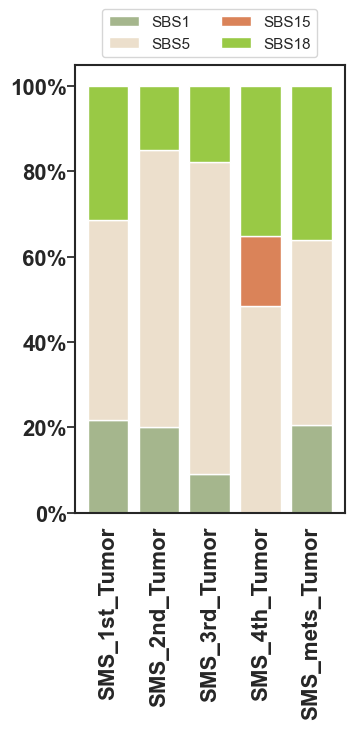

In [26]:
RESOLUTION1, RESOLUTION2 = 0.1, 0.01
RESOLUTION1, RESOLUTION2 = 0.001, 0.001
model.H_s_percentage = (model.H_s_grid[(RESOLUTION1, RESOLUTION2)] / model.H_s_grid[(RESOLUTION1, RESOLUTION2)].sum(axis=0) ) * 100
print ( model.H_s_percentage )

import palettable
import random

plt.rcParams["font.family"] = 'Arial'
fig, ax = plt.subplots ( nrows = 1, ncols = 1, figsize = (3.5, 8))
fig.subplots_adjust (wspace = 0.05, hspace = 0.03, bottom = 0.34, top = 0.90, left = 0.18, right = 0.95)

tabl = palettable.tableau.Tableau_20.mpl_colors [3:]
vivid_10 = palettable.cartocolors.qualitative.Vivid_10.mpl_colors [3:]
colorlist = [ "#A5B68D", "#ECDFCC", "#DA8359"] + vivid_10

model.H_s_percentage.T.plot( kind = 'bar', stacked = True, color = colorlist, width=0.8, ax = ax)
ax.set_xticklabels( model.H_s_percentage.columns, ha = "center",  fontdict = {"fontsize": 16, "fontweight" : 'bold' } )
ax.set_yticklabels( [ str (round(i)) + "%" for i in ax.get_yticks()] , fontdict = {"fontsize": 16, "fontweight" : 'bold' } )  

ax.tick_params (axis = 'x', rotation = 90,  bottom=False, top=False  )
ax.tick_params (axis = 'y', pad = 0  )

for axis in ['left', 'right', 'top', 'bottom']:
        ax.spines[axis].set_linewidth( 1.5 )

ax.legend( bbox_to_anchor=( 0.5 , 1), loc = 'lower center', ncol = len(model.H_s_percentage.index) / 2)

plt.show()

# fig.savefig ( "/data/project/Meningioma/41.Signature/03.by_time/03.MuSiCal/3+NatGen.stacked.pdf", dpi = 300 )
# fig.savefig ( "/data/project/Meningioma/41.Signature/Musical.all_stacked.pdf", dpi = 300 )